In [1]:
from lightkurve import DataCube, ErrorCube, DataFrame

%load_ext autoreload
%autoreload 2

In [2]:
from astropy.io import fits
import numpy as np

hdulist = fits.open(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

# Prepare DataCube

In [3]:
flux_array = hdulist[1].data["FLUX"].astype(float)
flux_err_array = hdulist[1].data["FLUX_ERR"].astype(float)
time = hdulist[1].data["TIME"].astype(float)
time_corr = hdulist[1].data["TIMECORR"].astype(float)
c0, r0 = hdulist[1].header["1CRV4P"], hdulist[1].header["2CRV4P"]
row, col = np.arange(flux_array.shape[1]) + r0, np.arange(flux_array.shape[2]) + c0
aper = flux_array.mean(axis=0) > 10000
bkg_aper = flux_array.mean(axis=0) < 4000

time_mask = hdulist[1].data["QUALITY"] == 0

In [4]:
flux = DataCube(
    flux_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"row": row},
    col_indices={"column": col},
)

flux_err = ErrorCube(
    flux_err_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"row": row},
    col_indices={"column": col},
)

In [5]:
flux, flux_err

(📘 DataCube (50, 6, 6), 📕 ErrorCube (50, 6, 6))

In [6]:
"data".ljust(20)

'data                '

In [7]:
flux

📘 DataCube (50, 6, 6) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

📘 DataCube (50, 6, 6)

In [8]:
flux_err

📕 ErrorCube (50, 6, 6) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 132

📕 ErrorCube (50, 6, 6)

# Tests

## Downsample

In [9]:
flux.downsample(5)

📘 DataCube (8, 6, 6) 
 
cadence         :	[ 8. 13. 18. 23. 28. 33. 38. 43.]
btjd            :	[1325.49092623 1325.59509193 1325.69925765 1325.8034234  1325.90758916
 1326.01175494 1326.11592074 1326.22008655]
spacecraft_time :	[1325.49017288 1325.59433951 1325.69850613 1325.80267276 1325.90683938
 1326.01100601 1326.11517263 1326.21933926]
row             :	[257 258 259 260 261 262]
column          :	[1628 1629 1630 1631 1632 1633]
type            :	<class 'lightkurve.datacube.DataCube'>



📘 DataCube (8, 6, 6)

In [10]:
flux_err.downsample(5)

📕 ErrorCube (8, 6, 6) 
 
cadence         :	[ 8. 13. 18. 23. 28. 33. 38. 43.]
btjd            :	[1325.49092623 1325.59509193 1325.69925765 1325.8034234  1325.90758916
 1326.01175494 1326.11592074 1326.22008655]
spacecraft_time :	[1325.49017288 1325.59433951 1325.69850613 1325.80267276 1325.90683938
 1326.01100601 1326.11517263 1326.21933926]
row             :	[257 258 259 260 261 262]
column          :	[1628 1629 1630 1631 1632 1633]
type            :	<class 'lightkurve.datacube.ErrorCube'>



📕 ErrorCube (8, 6, 6)

## Imposing an aperture mask where `mean`(flux of pixel) > 10,000

In [11]:
flux[:, aper]

,,series,8,9,14,15,16,19,20,21,22,25,26,27,28,31,32,33,34
,,row,258,258,259,259,259,260,260,260,260,261,261,261,261,262,262,262,262
,,column,1630,1631,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632
cadence,btjd,spacecraft_time,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,42657.632812,65179.886719,100720.773438,101675.906250,42470.730469,29425.457031,102240.070312,103746.945312,61337.554688,26175.996094,103074.070312,105171.984375,40686.078125,11072.824219,102138.585938,104423.625000,10715.317383
1,1325.345094,1325.344340,42648.261719,65202.703125,100720.617188,101675.750000,42489.433594,29410.039062,102239.914062,103746.789062,61370.964844,26143.367188,103073.914062,105171.820312,40717.785156,11068.058594,102138.429688,104423.468750,10720.024414
2,1325.365927,1325.365173,42482.433594,65449.781250,100720.492188,101689.953125,42563.906250,29321.394531,102246.984375,103753.929688,61504.335938,26041.806641,103073.796875,105179.046875,40789.992188,11046.513672,102138.304688,104430.640625,10729.130859
3,1325.386761,1325.386006,42606.925781,65420.988281,100713.601562,101675.585938,42549.976562,29406.074219,102240.031250,103746.632812,61454.304688,26063.630859,103066.804688,105164.296875,40812.726562,11046.653320,102131.343750,104423.312500,10736.232422
4,1325.407594,1325.406840,42386.238281,65640.031250,100706.531250,101682.976562,42573.464844,29310.171875,102232.921875,103739.585938,61588.140625,25998.742188,103059.632812,105164.523438,40953.453125,11042.083008,102124.218750,104416.218750,10752.752930
5,1325.428427,1325.427673,42606.902344,65784.171875,100713.570312,101682.953125,42648.289062,29356.253906,102232.820312,103746.835938,61604.894531,25948.199219,103059.531250,105164.500000,40889.960938,11023.171875,102124.132812,104416.195312,10745.757812
6,1325.449260,1325.448506,42708.250000,65836.125000,100720.695312,101690.148438,42652.933594,29379.376953,102239.992188,103746.859375,61593.714844,25933.828125,103066.757812,105171.882812,40880.855469,11016.144531,102131.304688,104423.539062,10738.701172


## Sum of flux in aperture, per cadence

In [12]:
flux[:, aper].sum(axis=1)

📉 DataSeries (50,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        1.152913e+06
1        1325.345094  1325.344340        1.152961e+06
2        1325.365927  1325.365173        1.153162e+06
3        1325.386761  1325.386006        1.153259e+06
4        1325.407594  1325.406840        1.153372e+06
5        1325.428427  1325.427673        1.153748e+06
6        1325.449260  1325.448506        1.153931e+06
7        1325.470093  1325.469340        1.153963e+06
8        1325.490926  1325.490173        1.154115e+06
9        1325.511759  1325.511006        1.154479e+06
10       1325.532593  1325.531840        1.154678e+06
11       1325.553426  1325.552673        1.154814e+06
12       1325.574259  1325.573506        1.155328e+06
13       1325.595092  1325.594340        1.155592e+06
14       1325.615925  1325.615173        1.155505e+06
15       1325.636758  1325.636006        1.155915e+06
16       1325.657591  1325.656839        1.156165e+06
17       1325.678425  132

## Sum of flux error in aperture, per cadence. 

In [13]:
flux_err[:, aper].sum(axis=1)

📈 ErrorSeries (50,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        29.298033
1        1325.345094  1325.344340        29.298598
2        1325.365927  1325.365173        29.301073
3        1325.386761  1325.386006        29.302346
4        1325.407594  1325.406840        29.303881
5        1325.428427  1325.427673        29.308586
6        1325.449260  1325.448506        29.310932
7        1325.470093  1325.469340        29.311349
8        1325.490926  1325.490173        29.313353
9        1325.511759  1325.511006        29.317865
10       1325.532593  1325.531840        29.320498
11       1325.553426  1325.552673        29.322088
12       1325.574259  1325.573506        29.328599
13       1325.595092  1325.594340        29.332034
14       1325.615925  1325.615173        29.330935
15       1325.636758  1325.636006        29.336104
16       1325.657591  1325.656839        29.339302
17       1325.678425  1325.677673        29.336464
18       1325.699258  13

# Check types when transformed

In [14]:
type(flux), type(flux_err)

(lightkurve.datacube.DataCube, lightkurve.datacube.ErrorCube)

In [15]:
type(flux[:, aper]), type(flux_err[:, aper])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [16]:
type(flux[:, 0, :]), type(flux_err[:, 0, :])
type(flux[:, :, 0]), type(flux_err[:, :, 0])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [17]:
type(flux[:, 0, 0]), type(flux_err[:, 0, 0])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [18]:
type(flux[:, aper].sum(axis=0)), type(flux_err[:, aper].sum(axis=0))
type(flux[:, aper].sum(axis=1)), type(flux_err[:, aper].sum(axis=1))

(lightkurve.dataseries.DataSeries, lightkurve.dataseries.ErrorSeries)

# Plot the light curve

<ErrorbarContainer object of 3 artists>

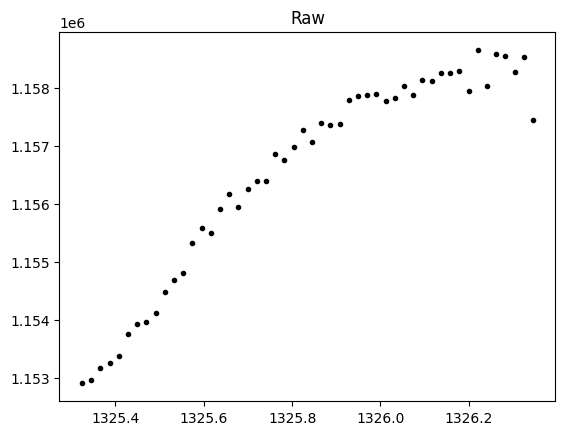

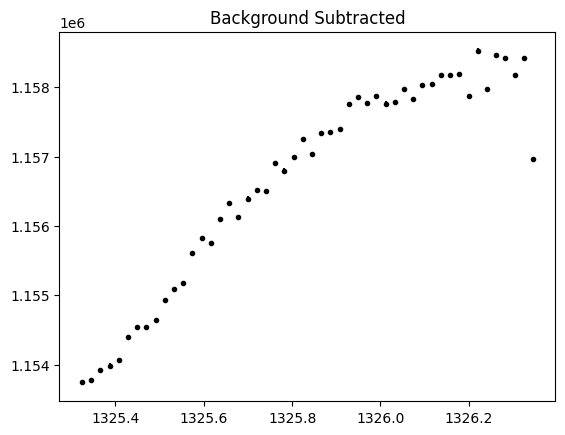

In [20]:
import matplotlib.pyplot as plt

time = np.asarray(flux.btjd)
bkg = flux[:, bkg_aper].mean(axis=1)
bkg_err = flux_err[:, bkg_aper].mean(axis=1)

bkg -= bkg.median()

lc = flux[:, aper].sum(axis=1)
lc_err = flux_err[:, aper].sum(axis=1)

plt.figure()
plt.title("Raw")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(.88e6, .94e6)

lc = flux[:, aper].sum(axis=1) - (bkg * aper.sum())
lc_err = flux_err[:, aper].sum(axis=1) + (bkg_err * aper.sum())

plt.figure()
plt.title("Background Subtracted")
plt.errorbar(time, lc.values, lc_err.values, ls="", marker=".", c="k")
# plt.ylim(0.88e6, 0.94e6)

## Info

repo: https://github.com/tessgi/secret/tree/christina-sketch1/src/lightkurve

# Milestones;

- ✅ Break the Cube, Frame, and Series classes into their own modules (cube.py, frame.py, series.py)
- ✅ Convert these demo functions into tests inside the package to fully test the functionality as users of lightkurve would need it. As you find any tests (breaking or passing) that cover functionality users need, add them to the tests.
    - ✅ To do this you will need to choose a reasonable piece of test data we can ship with the package. Crucially this must be small (ideally kb). You can trim down some tesscut data using lightkurve to add to the package
    - ❓ Confirm adjusted data product is appropriate and sufficient for tests
    - Trim to 50 frames
    - Put in tests/data
- ✅ Take a look at the pandas documentation and see if we can safely quiet the user warning that we have for adding our convenience functions (e.g. `flux.cadence`)
    - 🗒️ Add convenience functions to _metadata namespace
    - ❗️ Don't add existing attributes to this namespace, it messes up pandas at the core level somehow
- Currently there is an aggregate method for time. Create a similar aggregate method that will instead aggregate on columns so that;
    - ✅ DataCube.spatial_aggregate(...) -> returns a lower resolution datacube. e.g. sums pixels in row and column direction to create a lower resolution image
    - ✅ DataFrame.spatial_aggregate(...) -> returns a lower resolution dataframe
    - ✅ DataSeries has no spatial axis to aggregate
    - Create functions for ErrorCube and ErrorFrame
    - downsample methods more similar to time downsample
    - Think about binning to specific time/space points
- Tests for ErrorCubes
- Documentation
- Cube `__repr__`

- We'll come back to; can we have in lightkurve3 a way to take cubes, frames, series and convert to fits imagehdu, tablehdu, and columnhdu. 

## Smaller test data

In [ ]:
from lksearch import TESSSearch
from astropy.coordinates import SkyCoord

search_input = (84.291190, -80.469170)
search_input = SkyCoord(*search_input, unit="deg", frame="icrs")
search_result = TESSSearch(search_input, hlsp=False)

# You can filter two different ways to get the same result.
# search_result.filter_table(pipeline='TESScut')
downloads_table = search_result.tesscut.filter_table(sector=1).download(TESScut_size=6)
hdulist = fits.open(downloads_table["Local Path"][0])

In [9]:
hdulist = fits.open(
    "/Users/dkgiles/.lksearch/cache/mastDownload/TESSCut/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

In [113]:
hdulist[1].data = hdulist[1].data[:50]

In [115]:
hdulist.writeto(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits",
)

## Spatial aggregation

In [21]:
def single_cadence_frame(datacube, cadence):
    return DataFrame(
        datacube.to_array()[cadence],
        index=datacube.row[:: datacube.nrow],
        columns=datacube.column[: datacube.ncol],
    )

In [22]:
flux

📘 DataCube (50, 6, 6) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

📘 DataCube (50, 6, 6)

In [23]:
flux_lowres = flux.spatial_aggregate(3, 3)
flux_lowres

📘 DataCube (50, 3, 3) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

📘 DataCube (50, 3, 3)

#### change to 
`flux_lowres = flux.spatial_aggregate(factor=int)`

In [25]:
flux_lowres = flux.spatial_aggregate(4, 4)
flux_lowres

📘 DataCube (50, 4, 4) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

📘 DataCube (50, 4, 4)

In [26]:
single_cadence_frame(flux_lowres, 0)

,1628.333333,1629.666667,1631.333333,1632.666667
257.333333,3101.683838,23351.285461,36628.794800,8859.145630
258.666667,8886.329651,125772.485291,157577.511475,35942.926514
260.333333,29344.512939,175033.833008,197173.234375,50019.446777
261.666667,17663.325439,165756.032227,172538.795410,21117.401367


In [27]:
flux.downsample?

Signature: flux.downsample(nframes=5, level=-1)
Docstring: <no docstring>
File:      ~/Repositories/secret/src/lightkurve/mixins.py
Type:      method

In [28]:
flux.downsample(5)

📘 DataCube (8, 6, 6) 
 
cadence         :	[ 8. 13. 18. 23. 28. 33. 38. 43.]
btjd            :	[1325.49092623 1325.59509193 1325.69925765 1325.8034234  1325.90758916
 1326.01175494 1326.11592074 1326.22008655]
spacecraft_time :	[1325.49017288 1325.59433951 1325.69850613 1325.80267276 1325.90683938
 1326.01100601 1326.11517263 1326.21933926]
row             :	[257 258 259 260 261 262]
column          :	[1628 1629 1630 1631 1632 1633]
type            :	<class 'lightkurve.datacube.DataCube'>



📘 DataCube (8, 6, 6)

In [29]:
df0 = single_cadence_frame(flux, 0)
df0

,1628,1629,1630,1631,1632,1633
257,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
258,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703
259,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
260,5998.216797,29425.457031,102240.070312,103746.945312,61337.554688,7088.634766
261,4179.137207,26175.996094,103074.070312,105171.984375,40686.078125,4181.030273
262,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008


In [30]:
print(f"Sum of first 2x2: {df0.iloc[:2, :2].sum().sum()}")
df0.iloc[:2, :2]

Sum of first 2x2: 6432.709045410156


,1628,1629
257,972.539368,965.366943
258,2091.041260,2403.761475


In [31]:
df0.spatial_aggregate(3, 3)

,1628.5,1630.5,1632.5
257.5,6432.709045,109930.779541,19585.473389
259.5,45785.497559,408383.695312,119838.886719
261.5,44921.303223,414808.265625,59080.133789


### Spatial downsampling like the time downsampling

In [32]:
flux.spatial_downsample(2)

📘 DataCube (50, 3, 3) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

📘 DataCube (50, 3, 3)

In [33]:
flux.sum().sum()

61675674.96746826

In [34]:
flux.spatial_downsample(2).sum().sum()

61675674.96746826

In [35]:
flux[:, :-1].spatial_downsample(2)

📘 DataCube (50, 2, 3) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

📘 DataCube (50, 2, 3)

In [36]:
flux[:, :-2].sum().sum()

35747696.65374756

In [37]:
flux[:, :-1].spatial_downsample(2).sum().sum()

35747696.65374756

In [38]:
flux[:, :, :-1].spatial_downsample(2)

📘 DataCube (50, 3, 2) 
 
cadence         :	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
btjd            :	[1325.32426118 1325.34509431 1325.36592744 1325.38676057 1325.4075937
 1325.42842683 1325.44925996 1325.4700931  1325.49092623 1325.51175937
 1325.53259251 1325.55342565 1325.57425879 1325.59509193 1325.61592507
 1325.63675821 1325.65759136 1325.6784245  1325.69925765 1325.7200908
 1325.74092395 1325.76175709 1325.78259024 1325.8034234  1325.82425655
 1325.8450897  1325.86592285 1325.88675601 1325.90758916 1325.92842232
 1325.94925547 1325.97008863 1325.99092178 1326.01175494 1326.0325881
 1326.05342126 1326.07425442 1326.09508758 1326.11592074 1326.1367539
 1326.15758706 1326.17842022 1326.19925338 1326.22008655 1326.24091971
 1326.26175287 1326.28258604 1326.3034192  1326.32425236 1326.34508553]
spacecraft_time :	[1325.32350628 1325.34433961 1325.36517293 1325.38600626 1325

📘 DataCube (50, 3, 2)

In [39]:
flux[:, :, :-2].sum().sum()

51587640.84185791

In [40]:
flux[:, :, :-1].spatial_downsample(2).sum().sum()

51587640.84185791